In [22]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = os.path.join('..', 'data', 'fully combined')

qb_raw = pd.read_csv(os.path.join(DATA_DIR, 'qb_master.csv'))
rb_raw = pd.read_csv(os.path.join(DATA_DIR, 'rb_master.csv'))
te_raw = pd.read_csv(os.path.join(DATA_DIR, 'te_master.csv'))
wr_raw = pd.read_csv(os.path.join(DATA_DIR, 'wr_all_seasons_without_playoffs.csv'))

for name, df in [('QB', qb_raw), ('RB', rb_raw), ('TE', te_raw), ('WR', wr_raw)]:
    scol = 'Season' if 'Season' in df.columns else 'season'
    print(f'{name}: {df.shape[0]} redova x {df.shape[1]} kolona | Sezone: {df[scol].min()}-{df[scol].max()}')


QB: 845 redova x 188 kolona | Sezone: 1979-2025
RB: 622 redova x 115 kolona | Sezone: 1988-2025
TE: 351 redova x 70 kolona | Sezone: 1990-2025
WR: 5502 redova x 102 kolona | Sezone: 2015-2025


In [23]:
# QB: GS>0 filter (backup QB-ovi se uklanjaju - odluka iz EDA)
qb = qb_raw[qb_raw['GS'] > 0].copy()
qb['target'] = qb['Yds'] / qb['G'].replace(0, np.nan)

# RB: rushing yards per game
rb = rb_raw.copy()
rb['target'] = rb['Rush_Yds'] / rb['G'].replace(0, np.nan)

# TE: G>0 filter (igrači koji nisu odigrali ni jednu utakmicu — povreda, G=0 → target=NaN)
te = te_raw[te_raw['G'] > 0].copy()
te['target'] = te['Rec_Yds'] / te['G']

# WR: log transformacija na receiving_yards (odluka iz EDA - power-law distribucija)
# Clip na 0 pre log1p jer negativni yds/game su artefakti (penali)
wr = wr_raw.copy()
wr['rec_yds_per_game'] = wr['receiving_yards'] / wr['games_played'].replace(0, np.nan)
wr['target'] = np.log1p(wr['rec_yds_per_game'].clip(lower=0))

# Pregled
print('Ciljne promenljive:')
for name, df in [('QB', qb), ('RB', rb), ('TE', te)]:
    t = df['target']
    print(f'{name} (Yds/G):       mean={t.mean():.2f}, median={t.median():.2f}, min={t.min():.2f}, max={t.max():.2f}')

t_raw = wr['rec_yds_per_game']
t_log = wr['target']
print(f'WR (Yds/G raw):   mean={t_raw.mean():.2f}, median={t_raw.median():.2f}, min={t_raw.min():.2f}, max={t_raw.max():.2f}')
print(f'WR (log1p Yds/G): mean={t_log.mean():.3f}, median={t_log.median():.3f}, min={t_log.min():.3f}, max={t_log.max():.3f}')


Ciljne promenljive:
QB (Yds/G):       mean=223.72, median=231.05, min=0.00, max=371.20
RB (Yds/G):       mean=63.07, median=65.16, min=-0.23, max=131.06
TE (Yds/G):       mean=39.37, median=39.07, min=0.00, max=94.40
WR (Yds/G raw):   mean=22.39, median=16.57, min=-16.00, max=116.94
WR (log1p Yds/G): mean=2.737, median=2.866, min=0.000, max=4.770


In [24]:
# Award encoding — 5 binarnih kolona (odluka iz EDA)
# Kategorije: PB, AP-1, AP-2, MVP top5 (1-5), OPoY top5 (1-5)
# Isključujemo: Comeback Player of Year, rangiranja van top5

def encode_awards(series):
    def has(val, keywords):
        if pd.isna(val) or str(val).strip() == '':
            return 0
        return int(any(kw in str(val) for kw in keywords))
    
    df_enc = pd.DataFrame(index=series.index)
    df_enc['award_PB']       = series.apply(lambda v: has(v, ['PB']))
    df_enc['award_AP1']      = series.apply(lambda v: has(v, ['AP-1']))
    df_enc['award_AP2']      = series.apply(lambda v: has(v, ['AP-2']))
    df_enc['award_MVP_top5'] = series.apply(lambda v: has(v, ['MVP-1','MVP-2','MVP-3','MVP-4','MVP-5']))
    df_enc['award_OPoY_top5']= series.apply(lambda v: has(v, ['OPoY-1','OPoY-2','OPoY-3','OPoY-4','OPoY-5']))
    return df_enc

# QB i TE imaju 'Awards' (uppercase), RB ima 'awards' (lowercase)
qb = pd.concat([qb, encode_awards(qb['Awards'])], axis=1)
rb = pd.concat([rb, encode_awards(rb['awards'])], axis=1)
te = pd.concat([te, encode_awards(te['Awards'])], axis=1)
# WR nema awards kolonu — preskačemo

award_cols = ['award_PB','award_AP1','award_AP2','award_MVP_top5','award_OPoY_top5']
print('Award encoding — broj sezona po kategoriji:')
print(f'\n{"Nagrada":<20} {"QB":>6} {"RB":>6} {"TE":>6}')
print('-' * 38)
for col in award_cols:
    print(f'{col:<20} {qb[col].sum():>6} {rb[col].sum():>6} {te[col].sum():>6}')


Award encoding — broj sezona po kategoriji:

Nagrada                  QB     RB     TE
--------------------------------------
award_PB                262    152     93
award_AP1                40     52     28
award_AP2                37     39     20
award_MVP_top5           92     28      0
award_OPoY_top5          89     46      4


In [25]:
# ── Uklanjanje nepotrebnih kolona ─────────────────────────────────────────

# QB: metapodaci, defensive stats, elo (puno null-ova), special teams, duplikati
QB_DROP = (
    ['PlayerID', 'Pos', 'QBrec', 'Lng', 'TD%', 'Int%', 'Sk%', 'Y/G']  # metapodaci + duplikati
    + [c for c in qb.columns if c.startswith('def_')]                   # defensive stats
    + [c for c in qb.columns if c.startswith('elo_')]                   # elo kolone
    + ['snp_ST%', 'snp_special_teams']                                  # special teams snaps
)

# RB: metapodaci, defensive stats, special teams, duplikati kolona
RB_DROP = (
    ['PlayerID', 'Lg', 'Pos', 'Rush_Y/G', 'Rec_Y/G']                   # metapodaci + duplikati
    + [c for c in rb.columns if c.startswith('def_')]                   # defensive stats
    + ['snp_ST%', 'snp_ST_Snaps', 'snp_special_teams']                 # special teams
    + ['rec_success', 'catch_pct', 'Y/Tgt', 'Touch',                   # duplikati
       'yds_per_touch', 'yds_from_scrimmage', 'rush_receive_td', 'Rec_R/G']
)

# TE: metapodaci, special teams, defensive snaps
TE_DROP = (
    ['PlayerID', 'Pos']
    + ['snp_ST%', 'snp_ST_Snaps', 'snp_Def%', 'snp_Def_Snaps']
)

# WR: ID-evi, duplikati tima, quarter splits, win-prob splits, weather, game-state, betting
WR_DROP = (
    ['receiver_player_id', 'passer_player_id',                          # ID-evi
     'defteam', 'home_team', 'away_team', 'player_team']                # duplikati tima
    + [c for c in wr.columns if '_Q1' in c or '_Q2' in c
       or '_Q3' in c or '_Q4' in c]                                     # quarter splits
    + [c for c in wr.columns if c.startswith('yards_wp_')
       or c.startswith('receptions_wp_') or c.startswith('targets_wp_')]# win-prob splits
    + ['temp_f', 'humidity_pct', 'wind_mph',                            # weather
       'is_rain', 'is_snow', 'is_clear', 'is_dome', 'surface']         # stadium
    + ['avg_score_diff', 'avg_quarter', 'trailing_pct',                 # game-state
       'leading_pct', 'wp_var']
    + ['pregame_spread', 'pregame_total']                               # betting linije
)

# Primena — drop samo kolona koje postoje (ignorišemo ako neka već nedostaje)
qb.drop(columns=[c for c in QB_DROP if c in qb.columns], inplace=True)
rb.drop(columns=[c for c in RB_DROP if c in rb.columns], inplace=True)
te.drop(columns=[c for c in TE_DROP if c in te.columns], inplace=True)
wr.drop(columns=[c for c in WR_DROP if c in wr.columns], inplace=True)

# Statistika posle brisanja
print(f'{"Pozicija":<6} {"Pre":>6} {"Posle":>6} {"Izbačeno":>9}')
print('-' * 30)
for pos, raw, df in [('QB', qb_raw, qb), ('RB', rb_raw, rb), ('TE', te_raw, te), ('WR', wr_raw, wr)]:
    print(f'{pos:<6} {raw.shape[1]:>6} {df.shape[1]:>6} {raw.shape[1] - df.shape[1]:>9}')

print('\nPreostale kolone po poziciji:')
for pos, df in [('QB', qb), ('RB', rb), ('TE', te), ('WR', wr)]:
    print(f'\n{pos}: {list(df.columns)}')


Pozicija    Pre  Posle  Izbačeno
------------------------------
QB        188    123        65
RB        115     79        36
TE         70     70         0
WR        102     53        49

Preostale kolone po poziciji:

QB: ['Player', 'Season', 'Age', 'Team', 'G', 'GS', 'Cmp', 'Att', 'Cmp%', 'Yds', 'TD', 'Int', '1D', 'Succ%', 'Y/A', 'AY/A', 'Y/C', 'Rate', 'QBR', 'Sk', 'Yds_Lost', 'NY/A', 'ANY/A', '4QC', 'GWD', 'AV', 'Awards', 'adj_ANY/A+', 'adj_AY/A+', 'adj_Cmp%+', 'adj_Int%+', 'adj_NY/A+', 'adj_Rate+', 'adj_Sack%+', 'adj_TD%+', 'adj_Y/A+', 'adv_pass_pass_air_yds', 'adv_pass_pass_air_yds_per_att', 'adv_pass_pass_air_yds_per_cmp', 'adv_pass_pass_batted_passes', 'adv_pass_pass_blitzed', 'adv_pass_pass_drop_pct', 'adv_pass_pass_drops', 'adv_pass_pass_hits', 'adv_pass_pass_hurried', 'adv_pass_pass_on_target', 'adv_pass_pass_on_target_pct', 'adv_pass_pass_play_action', 'adv_pass_pass_play_action_pass_yds', 'adv_pass_pass_poor_throw_pct', 'adv_pass_pass_poor_throws', 'adv_pass_pass_pressured

In [26]:
# Analiza QB adv_ kolona: null% i korelacija sa osnovnim statistikama

adv_cols = [c for c in qb.columns if c.startswith('adv_')]
print(f'Ukupno adv_ kolona: {len(adv_cols)}\n')

# 1. Null procenat po koloni
null_pct = qb[adv_cols].isnull().mean() * 100
print('Null% po adv_ koloni:')
print(null_pct.sort_values(ascending=False).to_string())

# 2. Korelacija adv_ kolona sa osnovnim statistikama (Yds, Cmp, Att, TD, Rate itd.)
basic_stats = ['Yds', 'Cmp', 'Att', 'Cmp%', 'TD', 'Int', 'Rate', 'Sk', 'AV']
print('\n\nKorelacija adv_ kolona sa osnovnim statistikama (|r| > 0.85 = visoka duplikacija):')
print(f'{"adv kolona":<45} {"max |r|":>8}  {"najvise korelirana osnovna"}')
print('-' * 85)
for col in adv_cols:
    valid = qb[[col] + basic_stats].dropna()
    if len(valid) < 30:
        print(f'{col:<45} {"(premalo podataka)":>8}')
        continue
    corrs = valid[basic_stats].corrwith(valid[col]).abs()
    max_r = corrs.max()
    max_col = corrs.idxmax()
    marker = ' ◄ DUPLIKAT?' if max_r > 0.85 else ''
    print(f'{col:<45} {max_r:>8.3f}  {max_col}{marker}')


Ukupno adv_ kolona: 49

Null% po adv_ koloni:
adv_rr_rec_broken_tackles_per_rec      99.617347
adv_rr_rec_air_yds_per_rec             95.408163
adv_rr_rec_yac_per_rec                 95.408163
adv_rr_rec_adot                        93.877551
adv_rr_rec_drop_pct                    93.877551
adv_rr_rec_pass_rating                 93.877551
adv_rr_Rush_BrkTkl/A                   82.780612
adv_pass_pass_on_target_pct            71.045918
adv_pass_pass_on_target                70.918367
adv_pass_pass_rpo                      70.918367
adv_pass_pass_play_action_pass_yds     70.918367
adv_pass_pass_play_action              70.918367
adv_pass_pass_rpo_yds                  70.918367
adv_pass_pass_rpo_rush_att             70.918367
adv_pass_pass_rpo_pass_yds             70.918367
adv_pass_pass_rpo_pass_att             70.918367
adv_pass_pass_rpo_rush_yds             70.918367
adv_pass_rush_scrambles_yds_per_att    67.857143
adv_rr_Rush_YAC/A                      67.346939
adv_rr_Rush_BrkTkl     

In [27]:
# Izbacujemo sve adv_ kolone iz QB (67-100% null-ovi, duplikati osnovnih statistika)
adv_cols_to_drop = [c for c in qb.columns if c.startswith('adv_')]
qb.drop(columns=adv_cols_to_drop, inplace=True)

print(f'Izbačeno {len(adv_cols_to_drop)} adv_ kolona.')
print(f'QB shape: {qb.shape}')
print(f'Preostale kolone: {list(qb.columns)}')


Izbačeno 49 adv_ kolona.
QB shape: (784, 74)
Preostale kolone: ['Player', 'Season', 'Age', 'Team', 'G', 'GS', 'Cmp', 'Att', 'Cmp%', 'Yds', 'TD', 'Int', '1D', 'Succ%', 'Y/A', 'AY/A', 'Y/C', 'Rate', 'QBR', 'Sk', 'Yds_Lost', 'NY/A', 'ANY/A', '4QC', 'GWD', 'AV', 'Awards', 'adj_ANY/A+', 'adj_AY/A+', 'adj_Cmp%+', 'adj_Int%+', 'adj_NY/A+', 'adj_Rate+', 'adj_Sack%+', 'adj_TD%+', 'adj_Y/A+', 'rr_Fmb', 'rr_Rec', 'rr_Rec/G', 'rr_Rec_1D', 'rr_Rec_TD', 'rr_Rec_Y/G', 'rr_Rec_Yds', 'rr_Rush_1D', 'rr_Rush_A/G', 'rr_Rush_Att', 'rr_Rush_Lng', 'rr_Rush_Succ%', 'rr_Rush_TD', 'rr_Rush_Y/A', 'rr_Rush_Y/G', 'rr_Rush_Yds', 'rr_Tgt', 'rr_catch_pct', 'rr_rec_long', 'rr_rec_success', 'rr_rec_yds_per_rec', 'rr_rec_yds_per_tgt', 'rr_rush_receive_td', 'rr_touches', 'rr_yds_from_scrimmage', 'rr_yds_per_touch', 'snp_Def%', 'snp_Off%', 'snp_defense', 'snp_offense', 'Team_Changed', 'Prev_Season_Yds', 'target', 'award_PB', 'award_AP1', 'award_AP2', 'award_MVP_top5', 'award_OPoY_top5']


In [28]:
for pos, df in [('QB', qb), ('RB', rb), ('TE', te), ('WR', wr)]:
    print(f'\n{"="*60}')
    print(f'  {pos} — {df.shape[1]} kolona x {df.shape[0]} redova')
    print(f'{"="*60}')
    for i, col in enumerate(df.columns, 1):
        print(f'  {i:>3}. {col}')



  QB — 74 kolona x 784 redova
    1. Player
    2. Season
    3. Age
    4. Team
    5. G
    6. GS
    7. Cmp
    8. Att
    9. Cmp%
   10. Yds
   11. TD
   12. Int
   13. 1D
   14. Succ%
   15. Y/A
   16. AY/A
   17. Y/C
   18. Rate
   19. QBR
   20. Sk
   21. Yds_Lost
   22. NY/A
   23. ANY/A
   24. 4QC
   25. GWD
   26. AV
   27. Awards
   28. adj_ANY/A+
   29. adj_AY/A+
   30. adj_Cmp%+
   31. adj_Int%+
   32. adj_NY/A+
   33. adj_Rate+
   34. adj_Sack%+
   35. adj_TD%+
   36. adj_Y/A+
   37. rr_Fmb
   38. rr_Rec
   39. rr_Rec/G
   40. rr_Rec_1D
   41. rr_Rec_TD
   42. rr_Rec_Y/G
   43. rr_Rec_Yds
   44. rr_Rush_1D
   45. rr_Rush_A/G
   46. rr_Rush_Att
   47. rr_Rush_Lng
   48. rr_Rush_Succ%
   49. rr_Rush_TD
   50. rr_Rush_Y/A
   51. rr_Rush_Y/G
   52. rr_Rush_Yds
   53. rr_Tgt
   54. rr_catch_pct
   55. rr_rec_long
   56. rr_rec_success
   57. rr_rec_yds_per_rec
   58. rr_rec_yds_per_tgt
   59. rr_rush_receive_td
   60. rr_touches
   61. rr_yds_from_scrimmage
   62. rr_yds_per_

In [29]:
# QB: izbacujemo rr_* i snp_* kolone
qb_extra_drop = (
    [c for c in qb.columns if c.startswith('rr_')]
    + ['snp_Def%', 'snp_Off%', 'snp_defense', 'snp_offense']
)
qb.drop(columns=[c for c in qb_extra_drop if c in qb.columns], inplace=True)

# RB, TE, WR: izbacujemo adv_* i snp_* kolone
for df in [rb, te, wr]:
    drop = [c for c in df.columns if c.startswith('adv_') or c.startswith('snp_')]
    df.drop(columns=drop, inplace=True)

print(f'{"Pozicija":<6} {"Kolona":>7} {"Redova":>7}')
print('-' * 25)
for pos, df in [('QB', qb), ('RB', rb), ('TE', te), ('WR', wr)]:
    print(f'{pos:<6} {df.shape[1]:>7} {df.shape[0]:>7}')


Pozicija  Kolona  Redova
-------------------------
QB          44     784
RB          41     622
TE          42     350
WR          53    5502


In [30]:
# Dodatno čišćenje kolona

# Awards raw string — više ne treba (već enkodovano u award_* binarnim kolonama)
for df, col in [(qb, 'Awards'), (rb, 'awards'), (te, 'Awards')]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# QB: QBR — 33.9% null, strukturalni (postoji tek od ~2006), izbacujemo
if 'QBR' in qb.columns:
    qb.drop(columns=['QBR'], inplace=True)

# RB: receiving stats + kombinovane kolone sa null-ovima (rec komponenta nedostaje)
RB_DROP2 = ['Tgt', 'Rec', 'Rec_Yds', 'Rec_Y/R', 'Rec_TD', 'Rec_1D',
            'Rec_Succ%', 'Rec_Lng', 'Rec/G', 'Catch%', 'Rec_Y/Tgt', 'rec_long',
            'Y/Touch', 'Touches', 'Scrimmage_Yds', 'Rush_Rec_TD']
rb.drop(columns=[c for c in RB_DROP2 if c in rb.columns], inplace=True)

# TE: rushing stats (TE model predviđa receiving, rush stats su sekundarne)
TE_DROP2 = ['Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rush_1D', 'Rush_Y/G', 'Rush_A/G',
            'Touches', 'Y/Touch', 'Scrimmage_Yds', 'Rush_Succ%', 'Rush_Lng', 'Rush_Y/A']
te.drop(columns=[c for c in TE_DROP2 if c in te.columns], inplace=True)

# WR: defensive deviation stats
WR_DROP2 = ['def_targets_dev', 'def_receptions_dev', 'def_yards_dev',
            'def_tds_dev', 'def_epa_dev']
wr.drop(columns=[c for c in WR_DROP2 if c in wr.columns], inplace=True)

print(f'{"Pozicija":<6} {"Kolona":>7} {"Redova":>7}')
print('-' * 25)
for pos, df in [('QB', qb), ('RB', rb), ('TE', te), ('WR', wr)]:
    print(f'{pos:<6} {df.shape[1]:>7} {df.shape[0]:>7}')


Pozicija  Kolona  Redova
-------------------------
QB          42     784
RB          24     622
TE          29     350
WR          48    5502


In [31]:

for pos, df in [('QB', qb), ('RB', rb), ('TE', te), ('WR', wr)]:
    print(f'\n{"="*60}')
    print(f'  {pos} — {df.shape[1]} kolona x {df.shape[0]} redova')
    print(f'{"="*60}')
    for i, col in enumerate(df.columns, 1):
        print(f'  {i:>3}. {col}')



  QB — 42 kolona x 784 redova
    1. Player
    2. Season
    3. Age
    4. Team
    5. G
    6. GS
    7. Cmp
    8. Att
    9. Cmp%
   10. Yds
   11. TD
   12. Int
   13. 1D
   14. Succ%
   15. Y/A
   16. AY/A
   17. Y/C
   18. Rate
   19. Sk
   20. Yds_Lost
   21. NY/A
   22. ANY/A
   23. 4QC
   24. GWD
   25. AV
   26. adj_ANY/A+
   27. adj_AY/A+
   28. adj_Cmp%+
   29. adj_Int%+
   30. adj_NY/A+
   31. adj_Rate+
   32. adj_Sack%+
   33. adj_TD%+
   34. adj_Y/A+
   35. Team_Changed
   36. Prev_Season_Yds
   37. target
   38. award_PB
   39. award_AP1
   40. award_AP2
   41. award_MVP_top5
   42. award_OPoY_top5

  RB — 24 kolona x 622 redova
    1. Player
    2. Season
    3. Age
    4. Team
    5. G
    6. GS
    7. Rush_Att
    8. Rush_Yds
    9. Rush_TD
   10. Rush_1D
   11. Rush_Succ%
   12. Rush_Lng
   13. Rush_Y/A
   14. Rush_A/G
   15. Fmb
   16. av
   17. Team_Changed
   18. Prev_Season_Yds
   19. target
   20. award_PB
   21. award_AP1
   22. award_AP2
   23. award_MVP_to

In [32]:
# Analiza null vrednosti po poziciji
for pos, df in [('QB', qb), ('RB', rb), ('TE', te), ('WR', wr)]:
    null_counts = df.isnull().sum()
    has_nulls = null_counts[null_counts > 0]
    print(f'\n{"="*55}')
    print(f'  {pos} — kolone sa null vrednostima ({len(has_nulls)} od {df.shape[1]})')
    print(f'{"="*55}')
    if len(has_nulls) == 0:
        print('  Nema null vrednosti.')
    else:
        print(f'  {"Kolona":<35} {"Null#":>6}  {"Null%":>6}')
        print(f'  {"-"*52}')
        for col, cnt in has_nulls.sort_values(ascending=False).items():
            pct = cnt / len(df) * 100
            print(f'  {col:<35} {cnt:>6}  {pct:>5.1f}%')



  QB — kolone sa null vrednostima (11 od 42)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  adj_ANY/A+                              18    2.3%
  adj_Cmp%+                               18    2.3%
  adj_AY/A+                               18    2.3%
  adj_Rate+                               18    2.3%
  adj_Sack%+                              18    2.3%
  adj_Int%+                               18    2.3%
  adj_NY/A+                               18    2.3%
  adj_TD%+                                18    2.3%
  adj_Y/A+                                18    2.3%
  Y/C                                      1    0.1%
  Succ%                                    1    0.1%

  RB — kolone sa null vrednostima (4 od 24)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  Rush_Succ%                               3    0.5%
  Rush_Lng                                 3    0.5%
  Ru

In [33]:

# ── Kreiranje lag feature matrice (t-1 i t-2) ─────────────────────────────
# Model predviđa performansu sezone t koristeći SAMO podatke poznate prije sezone t:
#   - Sve statistike iz t-1 (_lag1) i t-2 (_lag2)
#   - Age i Team_Changed iz t (znamo ih prije sezone)
#   - target = Yds/G (ili log1p za WR) sezone t
#
# KONSEKUTIVNOST SEZONA [Provjera 2]:
#   Koristimo merge na (player, season) umjesto groupby.shift().
#   lag1 redovi dobijaju season+1, pa left join pronalazi TAČNO sezonu t-1.
#   Ako igrač nema podatke za t-1 (rookie, propuštena sezona), merge vraća NaN.
#   → Nema false pozitiva gdje bi starija sezona bila tretirana kao t-1.
#
# IMPUTACIJA POLITIKA [Promjena 6]:
#   lag2 NaN → 0  (nema historije 2 sezone unazad — neutralna vrijednost)
#   lag1 NaN → NaN (imputiraće se medijanom u koraku imputacije, ne nulom)

POS_CONFIG = {
    'QB': dict(df=qb, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'RB': dict(df=rb, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'TE': dict(df=te, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'WR': dict(df=wr, player_col='receiver_player_name', season_col='season',
               static_feats=['age', 'team_changed'],
               id_cols=['receiver_player_name', 'season', 'posteam']),
}

lagged = {}
for pos, cfg in POS_CONFIG.items():
    df       = cfg['df'].copy()
    pcol     = cfg['player_col']
    scol     = cfg['season_col']
    id_cols  = cfg['id_cols']
    static   = [c for c in cfg['static_feats'] if c in df.columns]

    # Kolone koje lagujemo: sve osim id-eva, statičkih feature-a i targeta
    lag_cols = [c for c in df.columns
                if c not in id_cols + static + ['target']]

    # Baza: id + statički feature-i + target (sve iz sezone t)
    base = df[id_cols + static + ['target']].copy()

    # Helper DF samo za lag join
    lag_src = df[[pcol, scol] + lag_cols].copy()

    # Lag 1 — pomjeramo sezonu za +1 da matchamo sa tekućom sezonom t
    lag1 = lag_src.rename(columns={c: f'{c}_lag1' for c in lag_cols}).copy()
    lag1[scol] = lag1[scol] + 1
    base = base.merge(lag1, on=[pcol, scol], how='left')

    # Lag 2 — pomjeramo sezonu za +2
    lag2 = lag_src.rename(columns={c: f'{c}_lag2' for c in lag_cols}).copy()
    lag2[scol] = lag2[scol] + 2
    base = base.merge(lag2, on=[pcol, scol], how='left')

    lag1_cols = [f'{c}_lag1' for c in lag_cols]
    lag2_cols = [f'{c}_lag2' for c in lag_cols]

    # lag2 → 0 (nema historije 2 sezone unazad)
    # lag1 → ostaju NaN → imputiraće se medijanom u koraku imputacije
    base[lag2_cols] = base[lag2_cols].fillna(0)

    # Ukloni redove bez targeta (edge cases G=0)
    base = base.dropna(subset=['target']).reset_index(drop=True)

    lagged[pos] = base

# Provjera — prikaz lag1 NaN redova (igrači bez prethodne sezone)
print(f'{"Pos":<5} {"Redova":>8} {"Kolona":>8} {"lag1 feats":>12} {"lag2 feats":>12} {"lag1 NaN redovi":>16}')
print('-' * 65)
for pos, df in lagged.items():
    lag1_cols = [c for c in df.columns if c.endswith('_lag1')]
    lag2_cols = [c for c in df.columns if c.endswith('_lag2')]
    lag1_nan_rows = df[lag1_cols].isnull().any(axis=1).sum()
    print(f'{pos:<5} {df.shape[0]:>8} {df.shape[1]:>8} {len(lag1_cols):>12} {len(lag2_cols):>12} {lag1_nan_rows:>16}')


Pos     Redova   Kolona   lag1 feats   lag2 feats  lag1 NaN redovi
-----------------------------------------------------------------
QB         784       78           36           36              115
RB         622       42           18           18               88
TE         350       52           23           23               46
WR        6405       91           43           43             1943


In [34]:

# Train/test split — temporalni: Season < 2024 = train, Season == 2024 = test
# Radi na lag feature matrici (lagged dict) — nema curenja podataka iz sezone t

POS_SPLIT = {
    'QB': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'RB': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'TE': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'WR': dict(id_cols=['receiver_player_name', 'season', 'posteam'],   season_col='season'),
}

splits = {}
for pos, cfg in POS_SPLIT.items():
    df       = lagged[pos]
    id_cols  = cfg['id_cols']
    scol     = cfg['season_col']

    train_df = df[df[scol] < 2024].copy()
    test_df  = df[df[scol] == 2024].copy()

    feat_cols = [c for c in df.columns if c not in id_cols + ['target']]

    X_train = train_df[feat_cols]
    y_train = train_df['target']
    X_test  = test_df[feat_cols]
    y_test  = test_df['target']

    splits[pos] = (X_train, X_test, y_train, y_test)

print(f'{"Pos":<5} {"X_train":>10} {"X_test":>8} {"y_train":>9} {"y_test":>8} {"features":>10}')
print('-' * 55)
for pos, (X_tr, X_te, y_tr, y_te) in splits.items():
    print(f'{pos:<5} {X_tr.shape[0]:>10} {X_te.shape[0]:>8} {y_tr.shape[0]:>9} {y_te.shape[0]:>8} {X_tr.shape[1]:>10}')


Pos      X_train   X_test   y_train   y_test   features
-------------------------------------------------------
QB           714       35       714       35         74
RB           552       34       552       34         38
TE           295       28       295       28         48
WR          5393      558      5393      558         87


In [35]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Binary kolone — ne skaliramo (već su 0/1, interpretabilnost se čuva)
# Award kolone sada imaju _lag1 / _lag2 sufiks (jer su lagovane)
# Team_Changed / team_changed ostaju statički (iz sezone t) → bez sufiksa
BINARY_COLS = [
    'award_PB_lag1',       'award_AP1_lag1',       'award_AP2_lag1',
    'award_MVP_top5_lag1', 'award_OPoY_top5_lag1',
    'award_PB_lag2',       'award_AP1_lag2',       'award_AP2_lag2',
    'award_MVP_top5_lag2', 'award_OPoY_top5_lag2',
    'Team_Changed', 'team_changed',
]

processed = {}

for pos, (X_train, X_test, y_train, y_test) in splits.items():

    # ── 1. Imputacija — fit samo na train ────────────────────────
    # PROMJENA 6: lag2 NaN → 0 (već urađeno u lag creation, ali eksplicitno ovdje)
    #             ostali NaN (lag1 za rookies) → MEDIJAN iz train seta
    #             Medijan je robusniji od mean-a na outlierima.

    lag2_present = [c for c in X_train.columns if c.endswith('_lag2')]
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train[lag2_present] = X_train[lag2_present].fillna(0)
    X_test[lag2_present]  = X_test[lag2_present].fillna(0)

    # Medijanska imputacija za preostale null-ove (lag1 za rookies)
    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns, index=X_train.index
    )
    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns, index=X_test.index
    )

    # ── 2. Standardizacija — samo numeričke (ne binary) kolone ───
    binary_present = [c for c in BINARY_COLS if c in X_train.columns]
    scale_cols     = [c for c in X_train.columns if c not in binary_present]

    scaler = StandardScaler()
    X_train_imp[scale_cols] = scaler.fit_transform(X_train_imp[scale_cols])
    X_test_imp[scale_cols]  = scaler.transform(X_test_imp[scale_cols])

    processed[pos] = (X_train_imp, X_test_imp, y_train, y_test)

# Provjera — nullovi nakon imputacije
print(f'{"Pos":<5} {"X_train nulls":>14} {"X_test nulls":>13} {"scaled cols":>12} {"binary cols":>12}')
print('-' * 60)
for pos, (X_tr, X_te, _, _) in processed.items():
    binary_present = [c for c in BINARY_COLS if c in X_tr.columns]
    scale_cols     = [c for c in X_tr.columns if c not in binary_present]
    print(f'{pos:<5} {X_tr.isnull().sum().sum():>14} {X_te.isnull().sum().sum():>13} '
          f'{len(scale_cols):>12} {len(binary_present):>12}')


Pos    X_train nulls  X_test nulls  scaled cols  binary cols
------------------------------------------------------------
QB                 0             0           63           11
RB                 0             0           27           11
TE                 0             0           37           11
WR                 0             0           86            1


In [36]:

# Pregled kolona i null vrijednosti u processed datasetu

for pos, (X_tr, X_te, y_tr, y_te) in processed.items():
    print(f'\n{"="*65}')
    print(f'  {pos} — X_train: {X_tr.shape[0]} redova x {X_tr.shape[1]} kolona')
    print(f'{"="*65}')
    
    # Sve kolone sa null statusom i tipom
    null_counts = X_tr.isnull().sum()
    print(f'\n  {"#":>4}  {"Kolona":<45} {"Tip":>8}  {"Nulls":>6}')
    print(f'  {"-"*70}')
    for i, col in enumerate(X_tr.columns, 1):
        null_n = null_counts[col]
        marker = ' ◄ NULL!' if null_n > 0 else ''
        print(f'  {i:>4}. {col:<45} {str(X_tr[col].dtype):>8}  {null_n:>6}{marker}')
    
    total_nulls = null_counts.sum()
    print(f'\n  Ukupno null-ova u X_train: {total_nulls}')
    print(f'  Ukupno null-ova u X_test:  {X_te.isnull().sum().sum()}')
    print(f'  y_train nulls: {y_tr.isnull().sum()} | y_test nulls: {y_te.isnull().sum()}')



  QB — X_train: 714 redova x 74 kolona

     #  Kolona                                             Tip   Nulls
  ----------------------------------------------------------------------
     1. Age                                            float64       0
     2. Team_Changed                                   float64       0
     3. G_lag1                                         float64       0
     4. GS_lag1                                        float64       0
     5. Cmp_lag1                                       float64       0
     6. Att_lag1                                       float64       0
     7. Cmp%_lag1                                      float64       0
     8. Yds_lag1                                       float64       0
     9. TD_lag1                                        float64       0
    10. Int_lag1                                       float64       0
    11. 1D_lag1                                        float64       0
    12. Succ%_lag1                

In [37]:

# ── GridSearchCV — optimizacija hiperparametara + cross-validacija ─────────
# PROMJENA 1: Umjesto fiksnih hiperparametara, koristimo GridSearchCV sa
# TimeSeriesSplit(n=5) za svaki model. Best estimator se koristi za test eval.
#
# Scoring: neg_mean_absolute_error (za WR — na log skali, ali relativo poređenje
# modela ostaje korektno; WR inverzija se radi pri test izveštaju).
#
# NAPOMENA za WR: GridSearchCV bira najbolje parametre u log1p prostoru.
# Ovo je prihvatljivo jer je redosljed modela po kvalitetu konzistentan
# između log i linear skale.

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np, pandas as pd, copy

MODEL_CONFIGS = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {},
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.1, 0.5, 0.9]},
    },
    'KNeighbors': {
        'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
        },
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
        },
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
        },
    },
}

tscv = TimeSeriesSplit(n_splits=5)

best_estimators = {}   # {pos: {model_name: fitted_best_estimator}}
cv_results      = {}   # {pos: DataFrame(Model, CV_MAE, Best_params)}

for pos, (X_tr, X_te, y_tr, y_te) in processed.items():
    best_estimators[pos] = {}
    rows = []
    log_note = ' [log skala]' if pos == 'WR' else ''

    print(f'\n{"="*68}')
    print(f'  {pos} — GridSearchCV (n_train={len(X_tr)}){log_note}')
    print(f'{"="*68}')
    print(f'  {"Model":<20} {"CV MAE":>8}  {"Najbolji parametri"}')
    print(f'  {"-"*65}')

    for name, cfg in MODEL_CONFIGS.items():
        if cfg['params']:
            grid = GridSearchCV(
                copy.deepcopy(cfg['model']),
                cfg['params'],
                cv=tscv,
                scoring='neg_mean_absolute_error',
                n_jobs=-1,
                refit=True,
            )
            grid.fit(X_tr, y_tr)
            best_model = grid.best_estimator_
            cv_mae     = -grid.best_score_
            best_params = grid.best_params_
        else:
            best_model = copy.deepcopy(cfg['model'])
            best_model.fit(X_tr, y_tr)
            cv_mae = -cross_val_score(
                copy.deepcopy(cfg['model']), X_tr, y_tr,
                cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
            ).mean()
            best_params = {}

        best_estimators[pos][name] = best_model
        rows.append({'Model': name, 'CV_MAE': round(cv_mae, 3), 'Best_params': str(best_params)})
        params_str = str(best_params) if best_params else '-'
        print(f'  {name:<20} {cv_mae:>8.3f}  {params_str}')

    cv_results[pos] = pd.DataFrame(rows).set_index('Model')

print('\nGridSearchCV završen za sve pozicije.')



  QB — GridSearchCV (n_train=714)
  Model                  CV MAE  Najbolji parametri
  -----------------------------------------------------------------
  LinearRegression       44.490  -
  Ridge                  35.096  {'alpha': 100.0}
  Lasso                  35.163  {'alpha': 1.0}
  ElasticNet             34.858  {'alpha': 0.1, 'l1_ratio': 0.1}
  KNeighbors             36.482  {'n_neighbors': 15, 'weights': 'uniform'}
  RandomForest           35.621  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
  XGBoost                35.286  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  LightGBM               35.529  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 15}

  RB — GridSearchCV (n_train=552)
  Model                  CV MAE  Najbolji parametri
  -----------------------------------------------------------------
  LinearRegression       19.705  -
  Ridge                  18.004  {'alpha': 100.0}
  Lasso      

In [38]:

# ── Test evaluacija na sezoni 2024 ─────────────────────────────────────────
# Koristimo best_estimators iz GridSearchCV (refit=True → već fitovani na
# punom X_train). Za WR: target je log1p(yds/g) → inverzno transformišemo
# za SVE metrike (MAE, RMSE, R²) → direktno usporedivo sa QB/RB/TE.

test_results = {}   # {pos: DataFrame sa test metrikama}
best_models  = {}   # {pos: (ime_modela, model_objekt)}

for pos, (X_tr, X_te, y_tr, y_te) in processed.items():
    rows = []
    is_wr = (pos == 'WR')

    print(f'\n{"="*60}')
    print(f'  {pos} — Test evaluacija (sezona 2024, n_test={len(X_te)})')
    if is_wr:
        print(f'  [WR: sve metrike na originalnoj yds/g skali (expm1)]')
    print(f'{"="*60}')
    print(f'  {"Model":<20} {"MAE":>8} {"RMSE":>8} {"R²":>8}  {"Best params"}')
    print(f'  {"-"*75}')

    for name, model in best_estimators[pos].items():
        preds = model.predict(X_te)

        if is_wr:
            # Inverz log1p → yds/g skala za sve metrike
            y_true_inv = np.expm1(y_te)
            y_pred_inv = np.expm1(preds)
            mae  = mean_absolute_error(y_true_inv, y_pred_inv)
            rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
            r2   = r2_score(y_true_inv, y_pred_inv)   # R² na yds/g skali
        else:
            mae  = mean_absolute_error(y_te, preds)
            rmse = np.sqrt(mean_squared_error(y_te, preds))
            r2   = r2_score(y_te, preds)

        rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
        best_params_str = cv_results[pos].loc[name, 'Best_params']
        print(f'  {name:<20} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f}  {best_params_str}')

    df_test = pd.DataFrame(rows).set_index('Model')
    test_results[pos] = df_test

    best_name = df_test['RMSE'].idxmin()
    best_models[pos] = (best_name, best_estimators[pos][best_name])
    print(f'\n  ★ Najbolji model ({pos}): {best_name} | RMSE={df_test.loc[best_name,"RMSE"]:.3f}')

print('\nFinalna test evaluacija završena.')



  QB — Test evaluacija (sezona 2024, n_test=35)
  Model                     MAE     RMSE       R²  Best params
  ---------------------------------------------------------------------------
  LinearRegression       34.113   45.809   -0.038  {}
  Ridge                  33.319   47.885   -0.134  {'alpha': 100.0}
  Lasso                  31.611   44.484    0.021  {'alpha': 1.0}
  ElasticNet             33.967   48.599   -0.168  {'alpha': 0.1, 'l1_ratio': 0.1}
  KNeighbors             33.592   44.035    0.041  {'n_neighbors': 15, 'weights': 'uniform'}
  RandomForest           31.824   41.557    0.146  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
  XGBoost                31.265   40.625    0.184  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  LightGBM               33.140   41.746    0.138  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 15}

  ★ Najbolji model (QB): XGBoost | RMSE=40.625

  RB — Test evaluacija (

In [39]:

# ── Sumarni prikaz GridSearchCV MAE + Test metrike + čuvanje best modela ──
import joblib, os

MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

print('GridSearchCV CV MAE vs Test rezultati\n')
print(f'{"Pos":<5} {"Model":<20} {"CV_MAE":>8} │ {"Test_MAE":>9} {"Test_RMSE":>10} {"Test_R²":>8}')
print('─' * 70)

for pos in ['QB', 'RB', 'TE', 'WR']:
    cv_df   = cv_results[pos]
    test_df = test_results[pos]
    best    = best_models[pos][0]

    for i, model_name in enumerate(MODEL_CONFIGS.keys()):
        if model_name not in test_df.index:
            continue
        marker = ' ★' if model_name == best else ''
        prefix = pos if i == 0 else ''
        cv_mae   = cv_df.loc[model_name, 'CV_MAE']
        test_row = test_df.loc[model_name]
        print(f'{prefix:<5} {model_name:<20} '
              f'{cv_mae:>8.3f} │ '
              f'{test_row["MAE"]:>9.3f} {test_row["RMSE"]:>10.3f} {test_row["R2"]:>8.3f}{marker}')
    print('─' * 70)

# Čuvanje best modela po poziciji
print('\nSačuvani modeli:')
for pos, (name, model) in best_models.items():
    path = os.path.join(MODELS_DIR, f'{pos}_best_model.joblib')
    joblib.dump(model, path)
    test_rmse = test_results[pos].loc[name, 'RMSE']
    best_params = cv_results[pos].loc[name, 'Best_params']
    print(f'  {pos}: {name} → RMSE={test_rmse:.3f} | params={best_params}')


GridSearchCV CV MAE vs Test rezultati

Pos   Model                  CV_MAE │  Test_MAE  Test_RMSE  Test_R²
──────────────────────────────────────────────────────────────────────
QB    LinearRegression       44.490 │    34.113     45.809   -0.038
      Ridge                  35.096 │    33.319     47.885   -0.134
      Lasso                  35.163 │    31.611     44.484    0.021
      ElasticNet             34.858 │    33.967     48.599   -0.168
      KNeighbors             36.482 │    33.592     44.035    0.041
      RandomForest           35.621 │    31.824     41.557    0.146
      XGBoost                35.286 │    31.265     40.625    0.184 ★
      LightGBM               35.529 │    33.140     41.746    0.138
──────────────────────────────────────────────────────────────────────
RB    LinearRegression       19.705 │    19.031     23.421    0.118
      Ridge                  18.004 │    20.345     24.155    0.062
      Lasso                  18.021 │    20.543     24.373    0.045
 

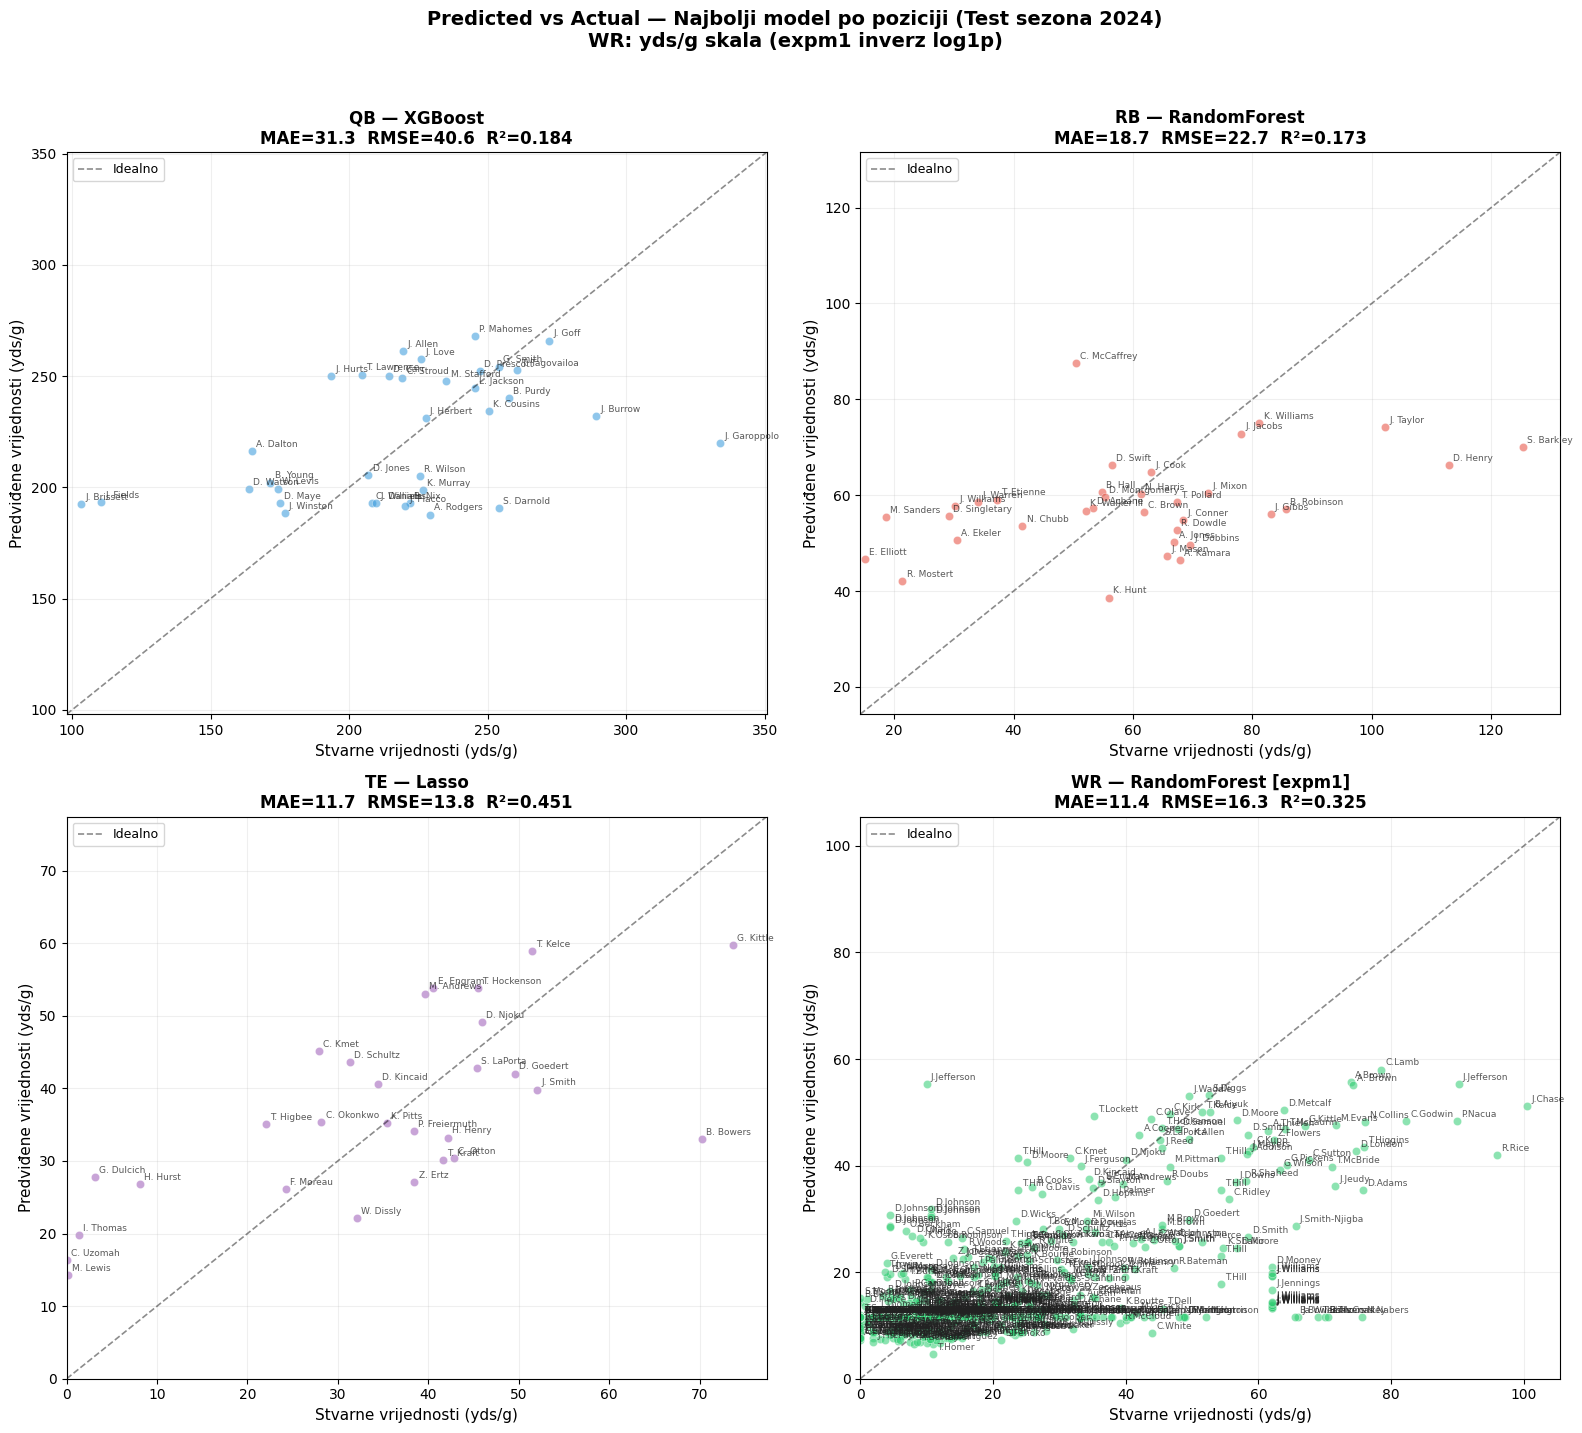

In [40]:

# ── Predicted vs Actual — scatter plotovi za sve pozicije ─────────────────
# WR: predikcije i stvarne vrijednosti se konvertuju expm1() → yds/g skala.
# Sve 4 pozicije su tako direktno usporedive na istoj skali (yds/g).

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLORS = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

# Dohvati imena igrača iz test seta (sezona 2024)
PLAYER_COL = {
    'QB': 'Player', 'RB': 'Player', 'TE': 'Player', 'WR': 'receiver_player_name'
}
SEASON_COL = {
    'QB': 'Season', 'RB': 'Season', 'TE': 'Season', 'WR': 'season'
}

player_names = {}
for pos in ['QB', 'RB', 'TE', 'WR']:
    pcol = PLAYER_COL[pos]
    scol = SEASON_COL[pos]
    test_df = lagged[pos][lagged[pos][scol] == 2024]
    player_names[pos] = test_df[pcol].values

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, pos in zip(axes.flat, ['QB', 'RB', 'TE', 'WR']):
    _, X_te, _, y_te = processed[pos]
    best_name, best_model = best_models[pos]
    preds = best_model.predict(X_te)
    names = player_names[pos]

    if pos == 'WR':
        y_actual = np.expm1(y_te.values)
        y_pred   = np.expm1(preds)
        scale_note = ' [expm1]'
    else:
        y_actual = y_te.values
        y_pred   = preds
        scale_note = ''

    mae  = test_results[pos].loc[best_name, 'MAE']
    rmse = test_results[pos].loc[best_name, 'RMSE']
    r2   = test_results[pos].loc[best_name, 'R2']

    ax.scatter(y_actual, y_pred, color=COLORS[pos], alpha=0.55, s=35,
               edgecolor='white', linewidth=0.4)

    lo = min(y_actual.min(), y_pred.min()) * 0.95
    hi = max(y_actual.max(), y_pred.max()) * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.45, linewidth=1.2, label='Idealno')

    # Dodaj imena igrača na tačke
    for x, y, name in zip(y_actual, y_pred, names):
        # Skrati ime: prvo slovo + prezime (npr. "P. Mahomes")
        parts = str(name).split()
        short = f'{parts[0][0]}. {" ".join(parts[1:])}' if len(parts) > 1 else name
        ax.annotate(
            short,
            xy=(x, y),
            xytext=(3, 3),
            textcoords='offset points',
            fontsize=6.5,
            alpha=0.75,
            color='#222222',
        )

    ax.set_xlabel('Stvarne vrijednosti (yds/g)', fontsize=11)
    ax.set_ylabel('Predviđene vrijednosti (yds/g)', fontsize=11)
    ax.set_title(
        f'{pos} — {best_name}{scale_note}\n'
        f'MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'Predicted vs Actual — Najbolji model po poziciji (Test sezona 2024)\n'
    'WR: yds/g skala (expm1 inverz log1p)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


In [41]:

# ══════════════════════════════════════════════════════════════════════════════
# ── Kalibracija evaluacije — Cross-Year Hold-Out (Walk-Forward)  ─────────────
# ══════════════════════════════════════════════════════════════════════════════
#
# POTPUNO ČISTA temporalna validacija — NULA data leakage:
#   Fold 1:  Train 1979–2020 → Test 2021
#   Fold 2:  Train 1979–2021 → Test 2022
#   Fold 3:  Train 1979–2022 → Test 2023
#   Fold 4:  Train 1979–2023 → Test 2024
#
# Na SVAKOM foldu (4 puta):
#   1. Imputer  — fituje se SAMO na train podacima tog folda
#   2. Scaler   — fituje se SAMO na train podacima tog folda
#   3. GridSearchCV — hiperparametri se biraju SAMO iz train podacima tog folda
#   4. Model    — trenira se SAMO na train podacima tog folda
#   → Model NIKADA ne vidi podatke iz test sezone — ni direktno ni indirektno

import ast, copy
import numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

FOLDS = [
    {'name': 'Fold 1', 'train_end': 2020, 'test_year': 2021},
    {'name': 'Fold 2', 'train_end': 2021, 'test_year': 2022},
    {'name': 'Fold 3', 'train_end': 2022, 'test_year': 2023},
    {'name': 'Fold 4', 'train_end': 2023, 'test_year': 2024},
]

POS_SCOL    = {'QB': 'Season', 'RB': 'Season', 'TE': 'Season', 'WR': 'season'}
POS_ID_COLS = {
    'QB': ['Player', 'Season', 'Team'],
    'RB': ['Player', 'Season', 'Team'],
    'TE': ['Player', 'Season', 'Team'],
    'WR': ['receiver_player_name', 'season', 'posteam'],
}

# Isti model configs kao i ranije — ali se GridSearchCV radi SVJEŽE po foldu
CAL_MODEL_CONFIGS = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {},
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.1, 0.5, 0.9]},
    },
    'KNeighbors': {
        'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
        },
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
        },
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
        },
    },
}

# ── Walk-forward petlja ──────────────────────────────────────────────────
cal_records = []       # svi rezultati po (pos, model, fold)
cal_best_per_pos = {}  # {pos: model_name sa najnižim avg RMSE kroz 4 folda}
cal_best_params = {}   # {(pos, model, fold): best_params} — za transparentnost

for pos in ['QB', 'RB', 'TE', 'WR']:
    scol      = POS_SCOL[pos]
    id_cols   = POS_ID_COLS[pos]
    df_full   = lagged[pos]
    is_wr     = (pos == 'WR')
    feat_cols = [c for c in df_full.columns if c not in id_cols + ['target']]

    print(f'\n{"═"*90}')
    print(f'  {pos} — Kalibracija evaluacije (Cross-Year Hold-Out)')
    if is_wr:
        print(f'  [WR: sve metrike na originalnoj yds/g skali — expm1 inverz]')
    print(f'{"═"*90}')

    model_avg_rmse = {}

    for model_name, mcfg in CAL_MODEL_CONFIGS.items():
        fold_mae, fold_rmse, fold_r2 = [], [], []
        fold_details = []

        for fold in FOLDS:
            train_end = fold['train_end']
            test_year = fold['test_year']

            # ══ STRIKTNI TEMPORALNI SPLIT ════════════════════════
            tr_mask = df_full[scol] <= train_end
            te_mask = df_full[scol] == test_year

            tr_df = df_full[tr_mask]
            te_df = df_full[te_mask]

            if len(te_df) == 0:
                fold_details.append(('N/A', 'N/A', 'N/A', {}))
                continue

            X_tr = tr_df[feat_cols].copy()
            y_tr = tr_df['target'].copy()
            X_te = te_df[feat_cols].copy()
            y_te = te_df['target'].copy()

            # ── 1. lag2 NaN → 0 ─────────────────────────────────
            lag2_c = [c for c in X_tr.columns if c.endswith('_lag2')]
            X_tr[lag2_c] = X_tr[lag2_c].fillna(0)
            X_te[lag2_c] = X_te[lag2_c].fillna(0)

            # ── 2. Imputacija — fit SAMO na train ovog folda ─────
            imp = SimpleImputer(strategy='median')
            X_tr_i = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
            X_te_i = pd.DataFrame(imp.transform(X_te),     columns=X_te.columns, index=X_te.index)

            # ── 3. Skaliranje — fit SAMO na train ovog folda ─────
            bin_c = [c for c in BINARY_COLS if c in X_tr.columns]
            num_c = [c for c in X_tr.columns if c not in bin_c]
            sc    = StandardScaler()
            X_tr_i[num_c] = sc.fit_transform(X_tr_i[num_c])
            X_te_i[num_c] = sc.transform(X_te_i[num_c])

            # ── 4. GridSearchCV — SAMO na train ovog folda ───────
            #    Hiperparametri se biraju isključivo iz podataka ≤ train_end
            tscv_fold = TimeSeriesSplit(n_splits=min(5, max(2, len(X_tr_i) // 50)))

            if mcfg['params']:
                grid = GridSearchCV(
                    copy.deepcopy(mcfg['model']),
                    mcfg['params'],
                    cv=tscv_fold,
                    scoring='neg_mean_absolute_error',
                    n_jobs=-1,
                    refit=True,
                )
                grid.fit(X_tr_i, y_tr)
                best_model = grid.best_estimator_
                best_p     = grid.best_params_
            else:
                best_model = copy.deepcopy(mcfg['model'])
                best_model.fit(X_tr_i, y_tr)
                best_p = {}

            # ── 5. Predikcija na test sezoni ─────────────────────
            preds = best_model.predict(X_te_i)

            # ── 6. WR inverz transformacija ──────────────────────
            if is_wr:
                y_ev = np.expm1(y_te.values)
                p_ev = np.expm1(preds)
            else:
                y_ev = y_te.values
                p_ev = preds

            mae  = mean_absolute_error(y_ev, p_ev)
            rmse = np.sqrt(mean_squared_error(y_ev, p_ev))
            r2   = r2_score(y_ev, p_ev)

            fold_mae.append(mae)
            fold_rmse.append(rmse)
            fold_r2.append(r2)
            fold_details.append((mae, rmse, r2, best_p))

            cal_records.append(dict(
                pos=pos, model=model_name,
                fold=fold['name'], train_end=train_end, test_year=test_year,
                n_train=len(tr_df), n_test=len(te_df),
                mae=mae, rmse=rmse, r2=r2,
                best_params=str(best_p),
            ))
            cal_best_params[(pos, model_name, fold['name'])] = best_p

        # Prosjeci preko 4 folda
        avg_mae  = np.mean(fold_mae)  if fold_mae  else np.nan
        avg_rmse = np.mean(fold_rmse) if fold_rmse else np.nan
        avg_r2   = np.mean(fold_r2)   if fold_r2   else np.nan
        model_avg_rmse[model_name] = avg_rmse

    # Ispis svega za ovu poziciju
    print(f'\n  {"Model":<20} │', end='')
    for f in FOLDS:
        print(f'  {f["name"]+" ("+str(f["test_year"])+")":>18}', end='')
    print(f'  │ {"AvgMAE":>8} {"AvgRMSE":>9} {"AvgR²":>7}')
    print(f'  {"─"*130}')

    for model_name in CAL_MODEL_CONFIGS.keys():
        sub = [r for r in cal_records if r['pos'] == pos and r['model'] == model_name]
        if not sub:
            continue
        row_str = f'  {model_name:<20} │'
        maes, rmses, r2s = [], [], []
        for f in FOLDS:
            match = [r for r in sub if r['test_year'] == f['test_year']]
            if match:
                row_str += f'  {match[0]["rmse"]:>7.2f} (R²={match[0]["r2"]:>6.3f})'
                maes.append(match[0]['mae'])
                rmses.append(match[0]['rmse'])
                r2s.append(match[0]['r2'])
            else:
                row_str += f'  {"N/A":>18}'

        avg_m  = np.mean(maes) if maes else np.nan
        avg_rm = np.mean(rmses) if rmses else np.nan
        avg_r  = np.mean(r2s) if r2s else np.nan
        row_str += f'  │ {avg_m:>8.3f} {avg_rm:>9.3f} {avg_r:>7.3f}'
        print(row_str)

    best_model_name = min(model_avg_rmse, key=model_avg_rmse.get)
    cal_best_per_pos[pos] = best_model_name
    print(f'\n  ★ Najbolji model ({pos}): {best_model_name}  |  Avg RMSE = {model_avg_rmse[best_model_name]:.3f}')

    # Prikaz kako se hiperparametri mijenjaju po foldu za best model
    print(f'\n  Hiperparametri {best_model_name} po foldu:')
    for f in FOLDS:
        key = (pos, best_model_name, f['name'])
        p = cal_best_params.get(key, {})
        print(f'    {f["name"]} (train ≤{f["train_end"]}): {p if p else "N/A (nema hiperparametara)"}')

cal_df = pd.DataFrame(cal_records)

# ══════════════════════════════════════════════════════════════════════════════
# ── Sumarni pregled + usporedba sa single-year testom ────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
print(f'\n\n{"═"*105}')
print(f'  SUMARNI PREGLED — Kalibracija (svježi GridSearchCV po foldu) vs Single-Year (2024) Test')
print(f'{"═"*105}')
print(f'  {"Pos":<5} {"Kal. pobjednik":<22} {"AvgMAE":>8} {"AvgRMSE":>9} {"AvgR²":>7}'
      f'  │  {"Single-2024 pobjednik":<22} {"RMSE_2024":>10}  │  {"Isti?":>5}')
print(f'  {"─"*105}')

for pos in ['QB', 'RB', 'TE', 'WR']:
    sub = cal_df[cal_df['pos'] == pos].groupby('model').agg(
        avg_mae=('mae','mean'), avg_rmse=('rmse','mean'), avg_r2=('r2','mean')
    )
    cal_best = sub['avg_rmse'].idxmin()
    cal_row  = sub.loc[cal_best]

    s24_name = best_models[pos][0]
    s24_rmse = test_results[pos].loc[s24_name, 'RMSE']

    same = '✓ DA' if cal_best == s24_name else '✗ NE'
    print(f'  {pos:<5} {cal_best:<22} {cal_row["avg_mae"]:>8.3f} {cal_row["avg_rmse"]:>9.3f} '
          f'{cal_row["avg_r2"]:>7.3f}  │  {s24_name:<22} {s24_rmse:>10.3f}  │  {same:>5}')

print(f'\n  PIPELINE PO FOLDU (potpuno svježe, 0 leakage):')
print(f'    1. Imputer  → fit na train ≤ t')
print(f'    2. Scaler   → fit na train ≤ t')
print(f'    3. GridSearchCV → hiperparametri birani SAMO iz train ≤ t')
print(f'    4. Model    → treniran SAMO na train ≤ t')
print(f'    5. Predict  → test = sezona t+1')
print(f'\nKalibracija evaluacije završena — 4 potpuno nezavisna treninga.')



══════════════════════════════════════════════════════════════════════════════════════════
  QB — Kalibracija evaluacije (Cross-Year Hold-Out)
══════════════════════════════════════════════════════════════════════════════════════════

  Model                │       Fold 1 (2021)       Fold 2 (2022)       Fold 3 (2023)       Fold 4 (2024)  │   AvgMAE   AvgRMSE   AvgR²
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  LinearRegression     │    59.87 (R²= 0.233)    35.07 (R²= 0.258)    66.05 (R²= 0.168)    45.81 (R²=-0.038)  │   37.172    51.699   0.155
  Ridge                │    60.49 (R²= 0.217)    36.06 (R²= 0.216)    69.58 (R²= 0.076)    47.89 (R²=-0.134)  │   38.043    53.502   0.094
  Lasso                │    59.74 (R²= 0.237)    34.72 (R²= 0.273)    69.53 (R²= 0.078)    44.48 (R²= 0.021)  │   37.141    52.119   0.152
  ElasticNet           │    60.11 (R²= 0.227)    35.03 (R²= 0.260)    69.22 (R²

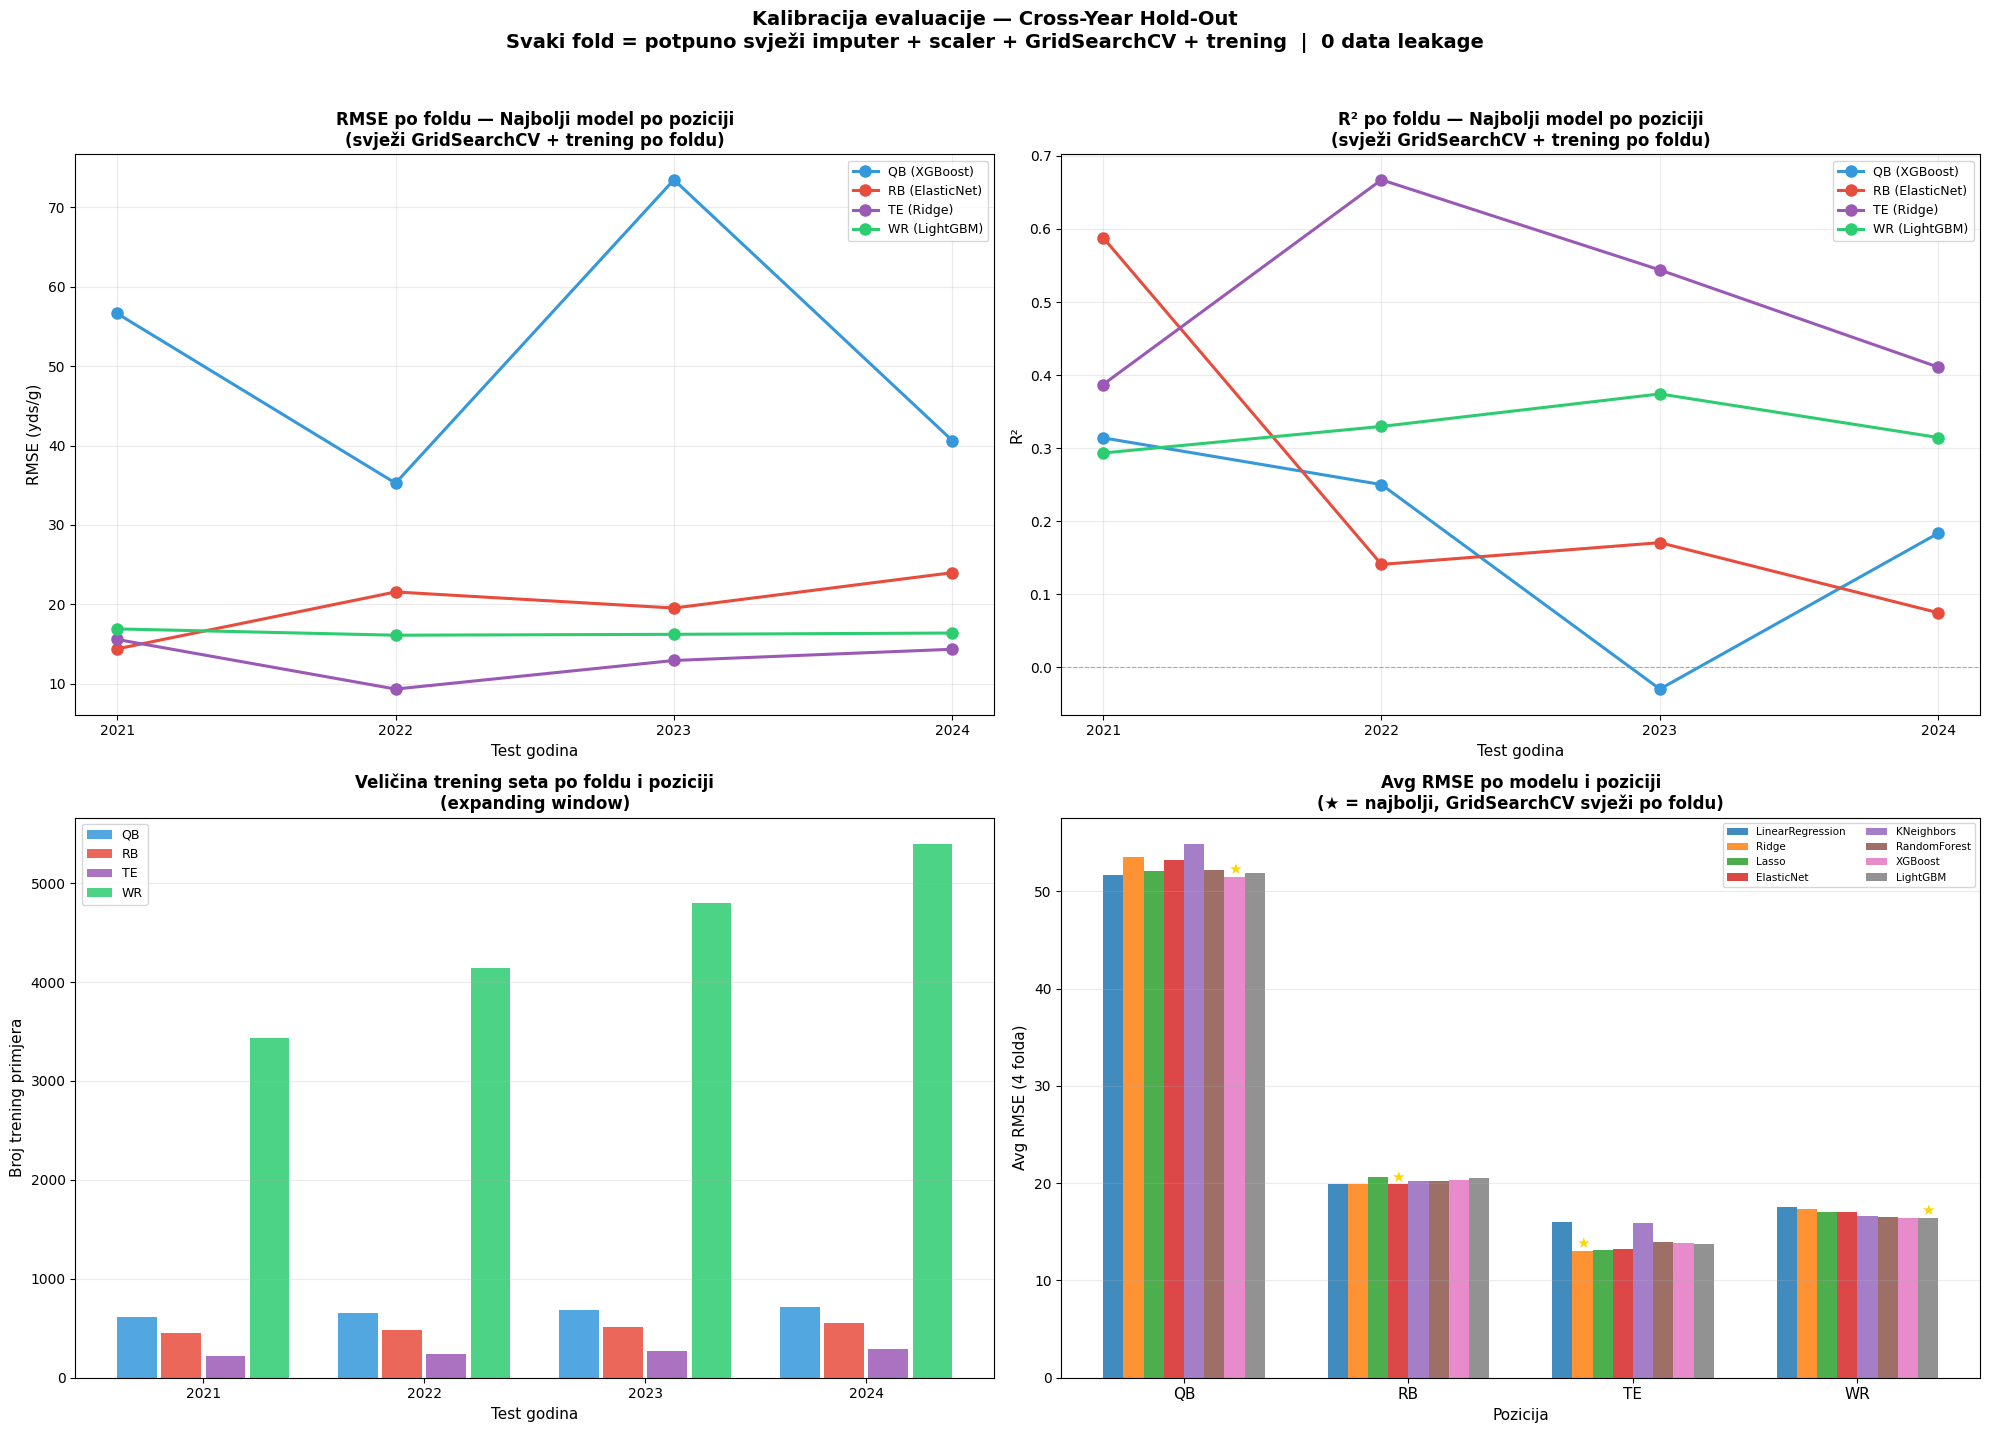


═══════════════════════════════════════════════════════════════════════════════════════════════
DETALJNI REZULTATI PO POZICIJI I FOLDU (sa parametrima)
═══════════════════════════════════════════════════════════════════════════════════════════════

QB  (★ Najbolji avg RMSE: XGBoost)
Train/test veličine:   2021: train=617, test=33  2022: train=650, test=31  2023: train=681, test=33  2024: train=714, test=35
                  RMSE_2021  RMSE_2022  RMSE_2023  RMSE_2024  R²_2021  R²_2022  R²_2023  R²_2024  AvgRMSE  AvgR2
model                                                                                                           
ElasticNet            60.11      35.03      69.22      48.60    0.227    0.260    0.086   -0.168   53.240  0.101
KNeighbors            62.56      38.25      74.51      44.04    0.163    0.118   -0.059    0.041   54.836  0.066
Lasso                 59.74      34.72      69.53      44.48    0.237    0.273    0.078    0.021   52.119  0.152
LightGBM              57

In [42]:

# ══════════════════════════════════════════════════════════════════════════════
# ── Vizualizacija kalibracije — 4 nezavisna treninga ─────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

POSITIONS = ['QB', 'RB', 'TE', 'WR']
colors_pos = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ── 1. RMSE po foldu — najbolji model po poziciji ────────────────────────
ax = axes[0, 0]
for pos in POSITIONS:
    best_m = cal_best_per_pos[pos]
    sub = cal_df[(cal_df['pos'] == pos) & (cal_df['model'] == best_m)].sort_values('test_year')
    ax.plot(sub['test_year'], sub['rmse'], marker='o', linewidth=2.2, markersize=8,
            label=f'{pos} ({best_m})', color=colors_pos[pos])
ax.set_xlabel('Test godina', fontsize=11)
ax.set_ylabel('RMSE (yds/g)', fontsize=11)
ax.set_title('RMSE po foldu — Najbolji model po poziciji\n(svježi GridSearchCV + trening po foldu)', fontsize=12, fontweight='bold')
ax.set_xticks([2021, 2022, 2023, 2024])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# ── 2. R² po foldu — najbolji model po poziciji ─────────────────────────
ax = axes[0, 1]
for pos in POSITIONS:
    best_m = cal_best_per_pos[pos]
    sub = cal_df[(cal_df['pos'] == pos) & (cal_df['model'] == best_m)].sort_values('test_year')
    ax.plot(sub['test_year'], sub['r2'], marker='o', linewidth=2.2, markersize=8,
            label=f'{pos} ({best_m})', color=colors_pos[pos])
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Test godina', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('R² po foldu — Najbolji model po poziciji\n(svježi GridSearchCV + trening po foldu)', fontsize=12, fontweight='bold')
ax.set_xticks([2021, 2022, 2023, 2024])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# ── 3. Train size po foldu ───────────────────────────────────────────────
ax = axes[1, 0]
for pos in POSITIONS:
    best_m = cal_best_per_pos[pos]
    sub = cal_df[(cal_df['pos'] == pos) & (cal_df['model'] == best_m)].sort_values('test_year')
    ax.bar([y + {'QB': -0.3, 'RB': -0.1, 'TE': 0.1, 'WR': 0.3}[pos] for y in sub['test_year']],
           sub['n_train'], width=0.18, label=f'{pos}', color=colors_pos[pos], alpha=0.85)
ax.set_xlabel('Test godina', fontsize=11)
ax.set_ylabel('Broj trening primjera', fontsize=11)
ax.set_title('Veličina trening seta po foldu i poziciji\n(expanding window)', fontsize=12, fontweight='bold')
ax.set_xticks([2021, 2022, 2023, 2024])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')

# ── 4. Avg RMSE bar chart — svi modeli, grupirano po poziciji ───────────
ax = axes[1, 1]
cal_summary = cal_df.groupby(['pos', 'model']).agg(avg_rmse=('rmse','mean')).reset_index()
model_names = list(CAL_MODEL_CONFIGS.keys())
x = np.arange(len(POSITIONS))
width = 0.09
for i, m_name in enumerate(model_names):
    vals = []
    for pos in POSITIONS:
        row = cal_summary[(cal_summary['pos'] == pos) & (cal_summary['model'] == m_name)]
        vals.append(row['avg_rmse'].values[0] if len(row) else 0)
    offset = (i - len(model_names)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=m_name, alpha=0.85)
    for j, pos in enumerate(POSITIONS):
        if m_name == cal_best_per_pos[pos]:
            ax.text(x[j] + offset, vals[j] + 0.3, '★', ha='center', fontsize=11, color='gold')
ax.set_xlabel('Pozicija', fontsize=11)
ax.set_ylabel('Avg RMSE (4 folda)', fontsize=11)
ax.set_title('Avg RMSE po modelu i poziciji\n(★ = najbolji, GridSearchCV svježi po foldu)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(POSITIONS, fontsize=11)
ax.legend(fontsize=7.5, ncol=2)
ax.grid(True, alpha=0.25, axis='y')

plt.suptitle('Kalibracija evaluacije — Cross-Year Hold-Out\n'
             'Svaki fold = potpuno svježi imputer + scaler + GridSearchCV + trening  |  0 data leakage',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Detaljna tabela po poziciji ──────────────────────────────────────────
print('\n' + '═'*95)
print('DETALJNI REZULTATI PO POZICIJI I FOLDU (sa parametrima)')
print('═'*95)

for pos in POSITIONS:
    sub = cal_df[cal_df['pos'] == pos]
    best_m = cal_best_per_pos[pos]

    rmse_piv = sub.pivot_table(index='model', columns='test_year', values='rmse').round(2)
    r2_piv   = sub.pivot_table(index='model', columns='test_year', values='r2').round(3)
    ntr_piv  = sub.pivot_table(index='model', columns='test_year', values='n_train', aggfunc='first')
    nte_piv  = sub.pivot_table(index='model', columns='test_year', values='n_test',  aggfunc='first')

    rmse_piv.columns = [f'RMSE_{y}' for y in rmse_piv.columns]
    r2_piv.columns   = [f'R²_{y}'   for y in r2_piv.columns]

    avg = sub.groupby('model').agg(AvgRMSE=('rmse','mean'), AvgR2=('r2','mean')).round(3)
    combined = pd.concat([rmse_piv, r2_piv, avg], axis=1)

    print(f'\n{pos}  (★ Najbolji avg RMSE: {best_m})')
    print(f'Train/test veličine: ', end='')
    for yr in [2021, 2022, 2023, 2024]:
        if yr in ntr_piv.columns:
            n = int(ntr_piv[yr].iloc[0])
            nt = int(nte_piv[yr].iloc[0])
            print(f'  {yr}: train={n}, test={nt}', end='')
    print()
    print(combined.to_string())

    # Hiperparametri po foldu za best model
    print(f'\n  Parametri {best_m} po foldu:')
    for _, row in sub[sub['model'] == best_m].sort_values('test_year').iterrows():
        print(f'    Train≤{row["train_end"]} → Test {row["test_year"]}: {row["best_params"]}')
